# Iterative Solvers

## Krylov Methods

Large sparse linear systems are usually solved without forming dense factorizations. Krylov methods build approximate solutions from repeated sparse matrix-vector products.

For symmetric positive definite matrices, conjugate gradient (CG) is the standard starting point {cite}`hestenes1952methods`.

In [1]:
import numpy as np
from scipy import sparse
from scipy.sparse import linalg as spla

In [2]:
def poisson_2d(n):
    T = sparse.diags(
        [-np.ones(n - 1), 4 * np.ones(n), -np.ones(n - 1)],
        offsets=[-1, 0, 1],
        format="csr",
    )
    I = sparse.eye(n, format="csr")
    off = sparse.diags([-np.ones(n - 1), -np.ones(n - 1)], offsets=[-1, 1], format="csr")
    return sparse.kron(I, T, format="csr") + sparse.kron(off, I, format="csr")

n = 80
A = poisson_2d(n)
b = np.ones(n * n)

print("unknowns:", A.shape[0])
print("nnz:", A.nnz)
print("density:", A.nnz / (A.shape[0] * A.shape[1]))

unknowns: 6400
nnz: 31680
density: 0.0007734375


## Residual Tracking

The callback records the residual norm after each CG iteration. For a production solver, preconditioning is often the difference between a useful method and an unusable one.

In [3]:
residuals = []

def callback(xk):
    residuals.append(np.linalg.norm(b - A @ xk))

x, info = spla.cg(A, b, rtol=1e-8, atol=0.0, maxiter=500, callback=callback)

print("CG info:", info)
print("iterations:", len(residuals))
print("initial residual:", residuals[0])
print("final residual:", residuals[-1])

CG info: 0
iterations: 149
initial residual: 353.27043465311385
final residual: 7.757758812211389e-07


## Jacobi Preconditioning

A simple diagonal, or Jacobi, preconditioner applies the inverse diagonal of the matrix. It is cheap and parallel, though often weaker than incomplete factorizations or multigrid.

In [4]:
diag_inv = 1.0 / A.diagonal()
M = spla.LinearOperator(A.shape, matvec=lambda v: diag_inv * v)
pcg_residuals = []

def pcg_callback(xk):
    pcg_residuals.append(np.linalg.norm(b - A @ xk))

x_pcg, pcg_info = spla.cg(A, b, rtol=1e-8, atol=0.0, maxiter=500, M=M, callback=pcg_callback)

print("PCG info:", pcg_info)
print("PCG iterations:", len(pcg_residuals))
print("PCG final residual:", pcg_residuals[-1])

PCG info: 0
PCG iterations: 149
PCG final residual: 7.757758812211389e-07


## Random Plot Test

This cell is a build test: if notebook outputs are captured, the plot below should appear in both the website and the PDF.

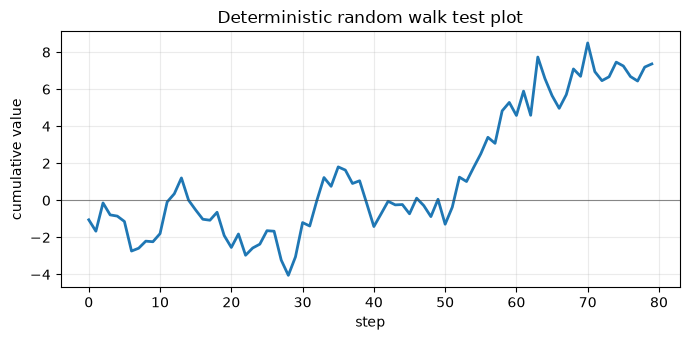

In [5]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260702)
steps = rng.normal(size=80)
walk = np.cumsum(steps)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(walk, color="#1f77b4", linewidth=2)
ax.axhline(0, color="#444444", linewidth=0.8, alpha=0.6)
ax.set_title("Deterministic random walk test plot")
ax.set_xlabel("step")
ax.set_ylabel("cumulative value")
ax.grid(True, alpha=0.25)
fig.tight_layout()

## Takeaways

Sparse solver design is a balance among storage, arithmetic, communication, and convergence. The best sparse format or solver depends on matrix structure and hardware. For nonsymmetric systems, GMRES is a standard Krylov method to compare against CG-style workflows {cite}`saad1986gmres`.